# Person 2: Recurrent model (BiGRU / BiLSTM over MFCC frame sequences)

This notebook runs `scripts/run_person2_recurrent.py`. All model code lives in `src/models/recurrent.py` and `src/preprocessing/sequences.py`. The notebook does not reimplement loading, the split, or preprocessing.

**Rules followed:** only `data/splits/shared_split.csv` is used (70/15/15, seed 42). Every tuning and early-stopping decision uses the validation split. The internal test split (`split == "test"`) is evaluated once, after the configuration is locked. The official Zindi `Test.csv` is never used.

**Runtime:** use a GPU runtime (*Runtime → Change runtime type → T4 GPU*). A full run takes roughly 1–2 hours on a T4. On a laptop CPU it would take days.

**Before running in Colab:** upload `Swahili_words.zip`, `Train.csv`, `Test.csv`, and `SampleSubmission.csv` to one Google Drive folder, and set `DRIVE_DATA_DIR` below to that folder.

In [1]:
# --- Settings ---------------------------------------------------------------
REPO_URL = "https://github.com/Orrie-Dan/NLP-and-Language-Technologies.git"
BRANCH = "main"
DRIVE_DATA_DIR = "/content/drive/MyDrive/swahili_audio"   # folder holding the 4 data files
DRIVE_RESULTS_DIR = "/content/drive/MyDrive/swahili_audio/person2_results"

In [2]:
import os, sys, shutil, subprocess
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    repo = Path("/content/NLP-and-Language-Technologies")
    if not repo.exists():
        subprocess.run(["git", "clone", "--branch", BRANCH, REPO_URL, str(repo)], check=True)
    os.chdir(repo)
    raw = repo / "data" / "raw"
    for name in ["Swahili_words.zip", "Train.csv", "Test.csv", "SampleSubmission.csv"]:
        if not (raw / name).exists():
            shutil.copy(Path(DRIVE_DATA_DIR) / name, raw / name)
else:
    # Running locally from notebooks/: move to the repository root.
    if Path.cwd().name == "notebooks":
        os.chdir("..")
print("Working directory:", Path.cwd())
print(sorted(p.name for p in Path("data/raw").iterdir()))

Mounted at /content/drive
Working directory: /content/NLP-and-Language-Technologies
['.gitkeep', 'SampleSubmission.csv', 'Swahili_words.zip', 'Test.csv', 'Train.csv']


In [3]:
%pip install -q -r requirements.txt
import torch
print("torch", torch.__version__, "| CUDA available:", torch.cuda.is_available(),
      "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "no GPU")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 99.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 128.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 947.5/947.5 kB 66.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.2/60.2 kB 5.7 MB/s eta 0:00:00
torch 2.11.0+cu130 | CUDA available: True | Tesla T4


## Run the experiment

The first time, this extracts 13-coefficient MFCC frame sequences for all 4,200 labelled clips (cached in `results/models/recurrent/cache/`). It then:

1. **Validation search.** One factor changes at a time and the best validation macro-F1 is carried forward: cell and direction (BiGRU, BiLSTM, GRU, LSTM), input features (static MFCC vs MFCC + Δ + ΔΔ), temporal resolution (10 ms frames vs 3 stacked frames = 30 ms), pooling (masked mean vs last state), hidden size (64/128/256), and dropout (0.15/0.3/0.5).
2. **Locked test evaluation.** The selected model is evaluated once on the internal test split.
3. **Seed robustness.** The same locked configuration is retrained with seeds 43 and 44.

In [4]:
!python scripts/run_person2_recurrent.py --device auto

Device: cuda | output: results/models/recurrent
Loaded shared split: 4200 rows
Loaded labels from Train.csv: 4200 rows
Joined labels successfully
Train: 2940 | Validation: 630 | Test: 630
Classes: hapana, kumi, mbili, moja, nane, ndio, nne, saba, sita, tano, tatu, tisa
MFCC sequences 250/4200
MFCC sequences 500/4200
MFCC sequences 750/4200
MFCC sequences 1000/4200
MFCC sequences 1250/4200
MFCC sequences 1500/4200
MFCC sequences 1750/4200
MFCC sequences 2000/4200
MFCC sequences 2250/4200
MFCC sequences 2500/4200
MFCC sequences 2750/4200
MFCC sequences 3000/4200
MFCC sequences 3250/4200
MFCC sequences 3500/4200
MFCC sequences 3750/4200
MFCC sequences 4000/4200
MFCC frames per clip: min 246, median 430, max 798
Stage: cell_and_direction
  [bigru seed=42] epoch   1 train_loss=2.455 val_loss=2.401 val_macro_f1=0.119 (best 0.119 @ 1)
  [bigru seed=42] epoch   5 train_loss=0.521 val_loss=0.413 val_macro_f1=0.898 (best 0.898 @ 5)
  [bigru seed=42] epoch  10 train_loss=0.077 val_loss=0.193 val_

## Results

In [5]:
import json
import pandas as pd
from IPython.display import Image, display

out = Path("results/models/recurrent")
fig = Path("results/figures/recurrent")
pd.set_option("display.precision", 4)

print("Validation search (all runs):")
display(pd.read_csv(out / "validation_experiments.csv")[
    ["stage", "run", "same_as", "cell", "bidirectional", "feature_streams", "frame_stack",
     "pooling", "hidden_size", "dropout", "best_epoch", "n_parameters", "val_accuracy", "val_macro_f1"]])

print("Selected configuration:")
print(json.dumps(json.loads((out / "selected_config.json").read_text()), indent=2))

Validation search (all runs):


,stage,run,same_as,cell,bidirectional,feature_streams,frame_stack,pooling,hidden_size,dropout,best_epoch,n_parameters,val_accuracy,val_macro_f1
0,cell_and_direction,bigru,bigru,gru,True,3,1,mean,128,0.30,21,429324,0.9603,0.9605
1,cell_and_direction,bilstm,bilstm,lstm,True,3,1,mean,128,0.30,34,571404,0.9524,0.9528
2,cell_and_direction,gru_unidirectional,gru_unidirectional,gru,False,3,1,mean,128,0.30,37,165516,0.9365,0.9365
3,cell_and_direction,lstm_unidirectional,lstm_unidirectional,lstm,False,3,1,mean,128,0.30,32,220172,0.9365,0.9365
4,input_features,static_mfcc_only,static_mfcc_only,gru,True,1,1,mean,128,0.30,20,409356,0.9492,0.9494
5,input_features,mfcc_deltas,bigru,gru,True,3,1,mean,128,0.30,21,429324,0.9603,0.9605
6,temporal_resolution,frames_10ms,bigru,gru,True,3,1,mean,128,0.30,21,429324,0.9603,0.9605
7,temporal_resolution,stacked_frames_30ms,stacked_frames_30ms,gru,True,3,3,mean,128,0.30,8,489228,0.9619,0.9622
8,pooling,mean_pooling,stacked_frames_30ms,gru,True,3,3,mean,128,0.30,8,489228,0.9619,0.9622
9,pooling,last_state_pooling,last_state_pooling,gru,True,3,3,last,128,0.30,9,489228,0.0857,0.0864


Selected configuration:
{
  "selected": {
    "name": "dropout_0.5",
    "cell": "gru",
    "bidirectional": true,
    "hidden_size": 256,
    "num_layers": 2,
    "dropout": 0.5,
    "pooling": "mean",
    "feature_streams": 3,
    "frame_stack": 3,
    "learning_rate": 0.001,
    "weight_decay": 0.0001,
    "batch_size": 32,
    "max_epochs": 60,
    "patience": 10,
    "grad_clip": 1.0
  },
  "selection_rule": "Greedy one-factor-at-a-time search; keep the highest validation macro-F1.",
  "selected_val_macro_f1": 0.9731832618837539
}


In [6]:
final = json.loads((out / "final_recurrent_results.json").read_text())
classical = pd.read_csv("results/classical/final_classical_results.csv")
comparison = pd.concat([
    classical[["model", "accuracy", "macro_f1", "weighted_f1", "macro_precision", "macro_recall"]],
    pd.DataFrame([{"model": f"recurrent ({final['selected_run']})", **final["test"]}]),
], ignore_index=True)
print("Internal test comparison:")
display(comparison)
print("Seed robustness (locked configuration):")
display(pd.read_csv(out / "seed_robustness.csv"))
print("Accuracy by clip duration (internal test):")
display(pd.read_csv(out / "test_accuracy_by_duration.csv"))

Internal test comparison:


,model,accuracy,macro_f1,weighted_f1,macro_precision,macro_recall,macro_roc_auc
0,logistic_regression,0.3810,0.3796,0.3798,0.3824,0.3808,NaN
1,linear_svm,0.3952,0.3855,0.3857,0.3845,0.3950,NaN
2,recurrent (dropout_0.5),0.9587,0.9587,0.9587,0.9595,0.9588,0.9976


Seed robustness (locked configuration):


,seed,best_epoch,val_macro_f1,test_accuracy,test_macro_f1,test_weighted_f1,test_macro_precision,test_macro_recall,test_macro_roc_auc
0,42,26.0000,0.9732,0.9587,0.9587,0.9587,0.9595,0.9588,0.9976
1,43,7.0000,0.9700,0.9476,0.9480,0.9480,0.9501,0.9476,0.9962
2,44,19.0000,0.9699,0.9571,0.9571,0.9571,0.9577,0.9571,0.9977
3,mean,17.3333,0.9710,0.9545,0.9546,0.9546,0.9557,0.9545,0.9972
4,std,9.6090,0.0019,0.0060,0.0058,0.0057,0.0050,0.0060,0.0008


Accuracy by clip duration (internal test):


,duration_bin,accuracy,n_clips
0,< 4 s,0.9662,207
1,4–5 s,0.9735,264
2,5–8 s,0.9457,129
3,≥ 8 s (truncated),0.8333,30


validation_experiments


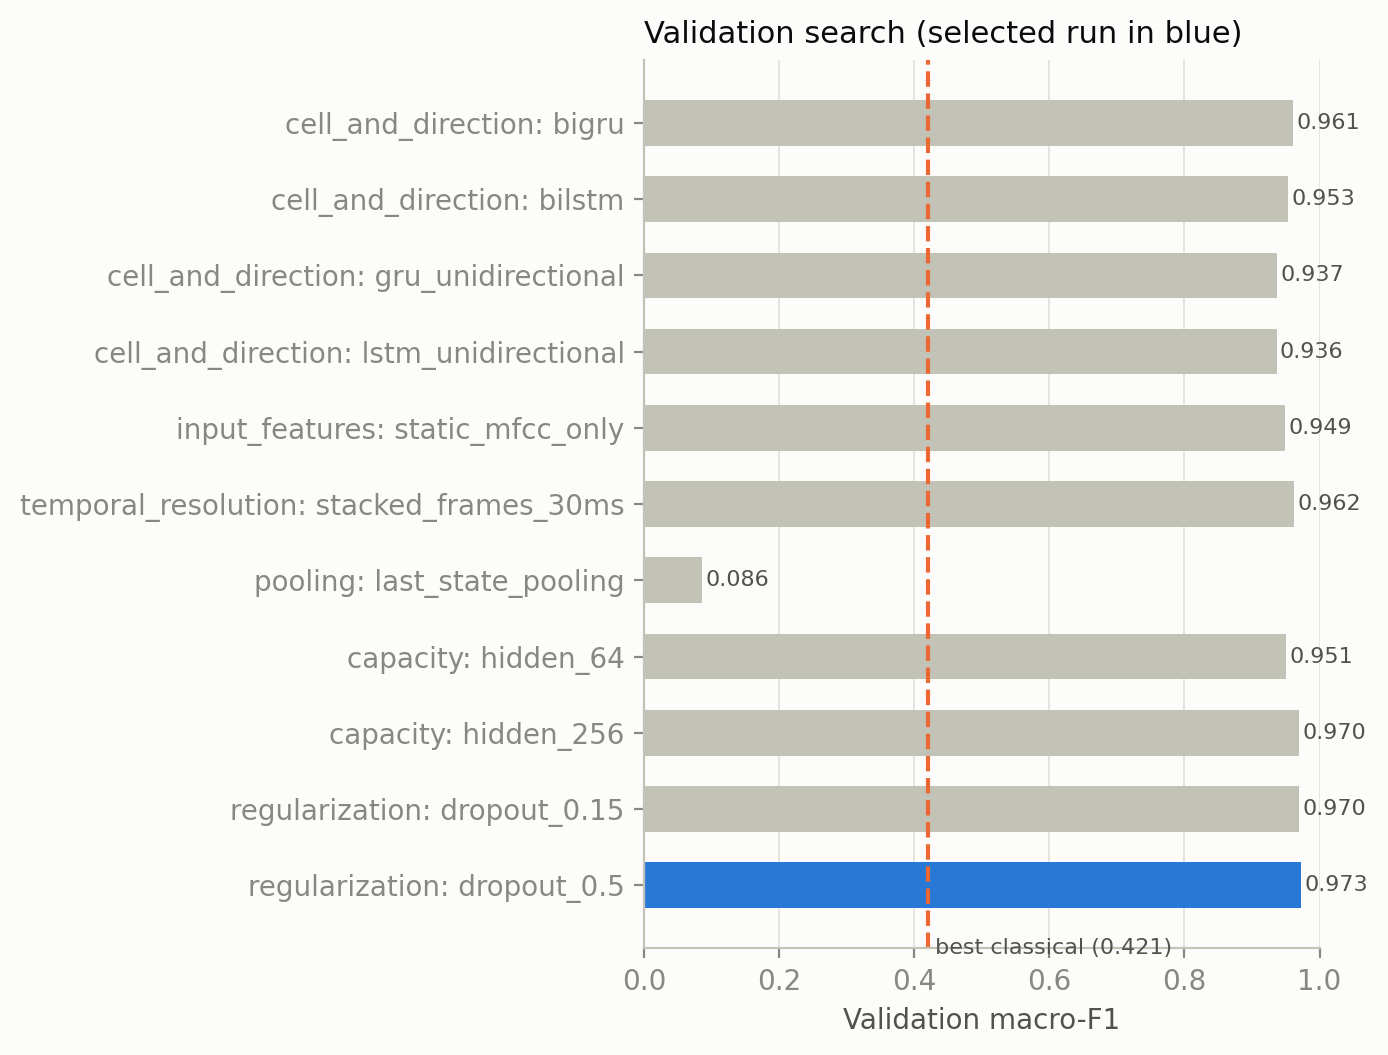

learning_curves


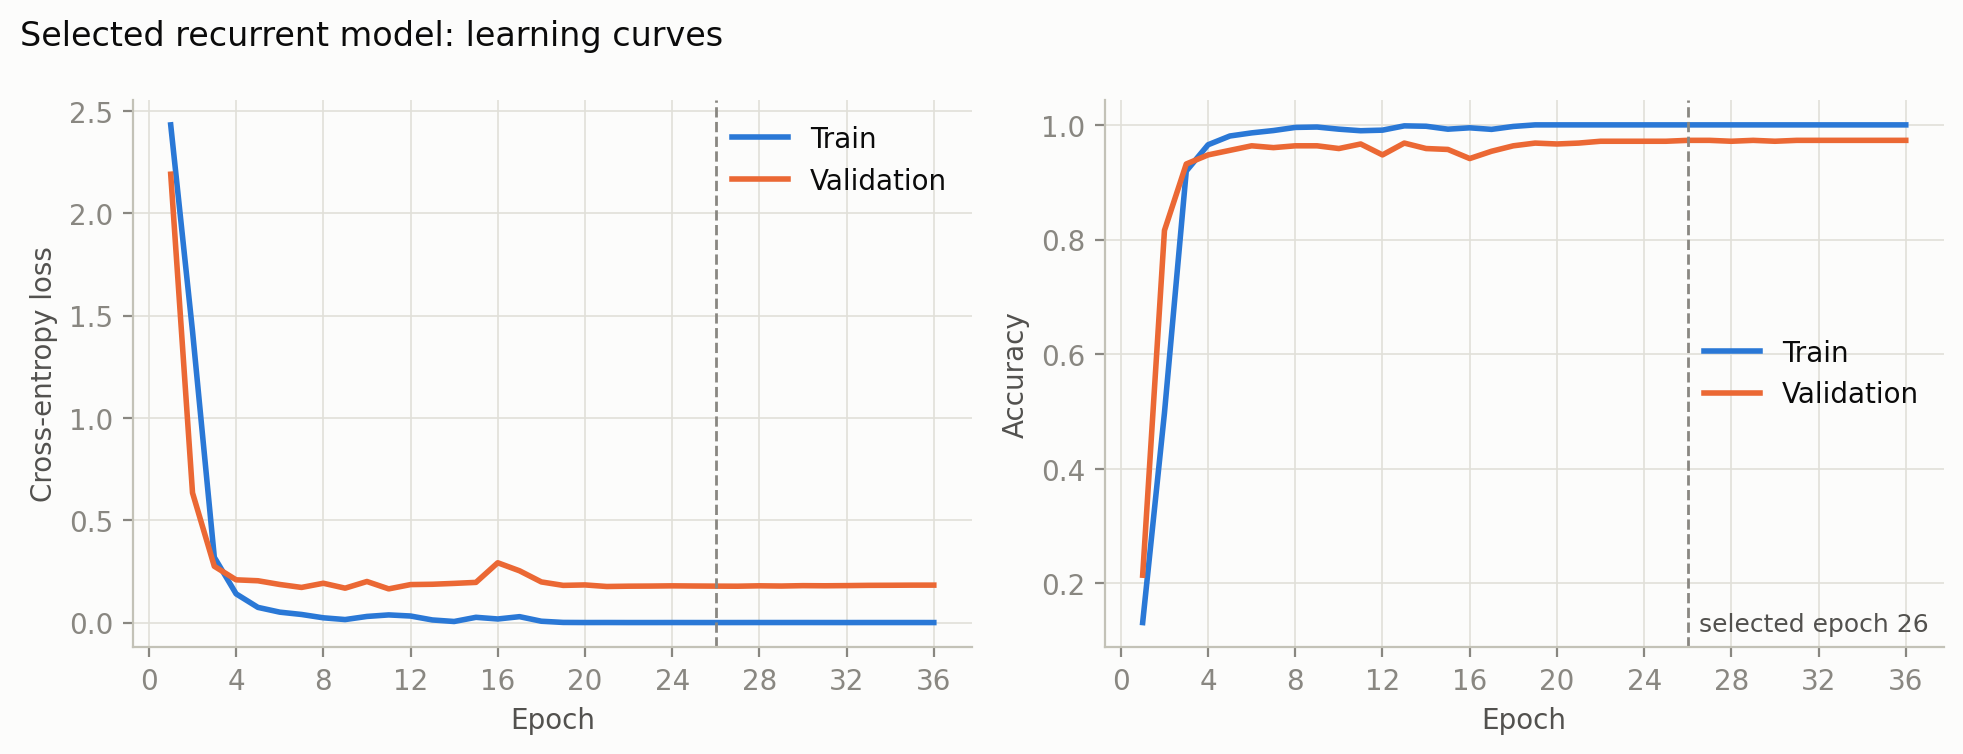

test_confusion_matrix


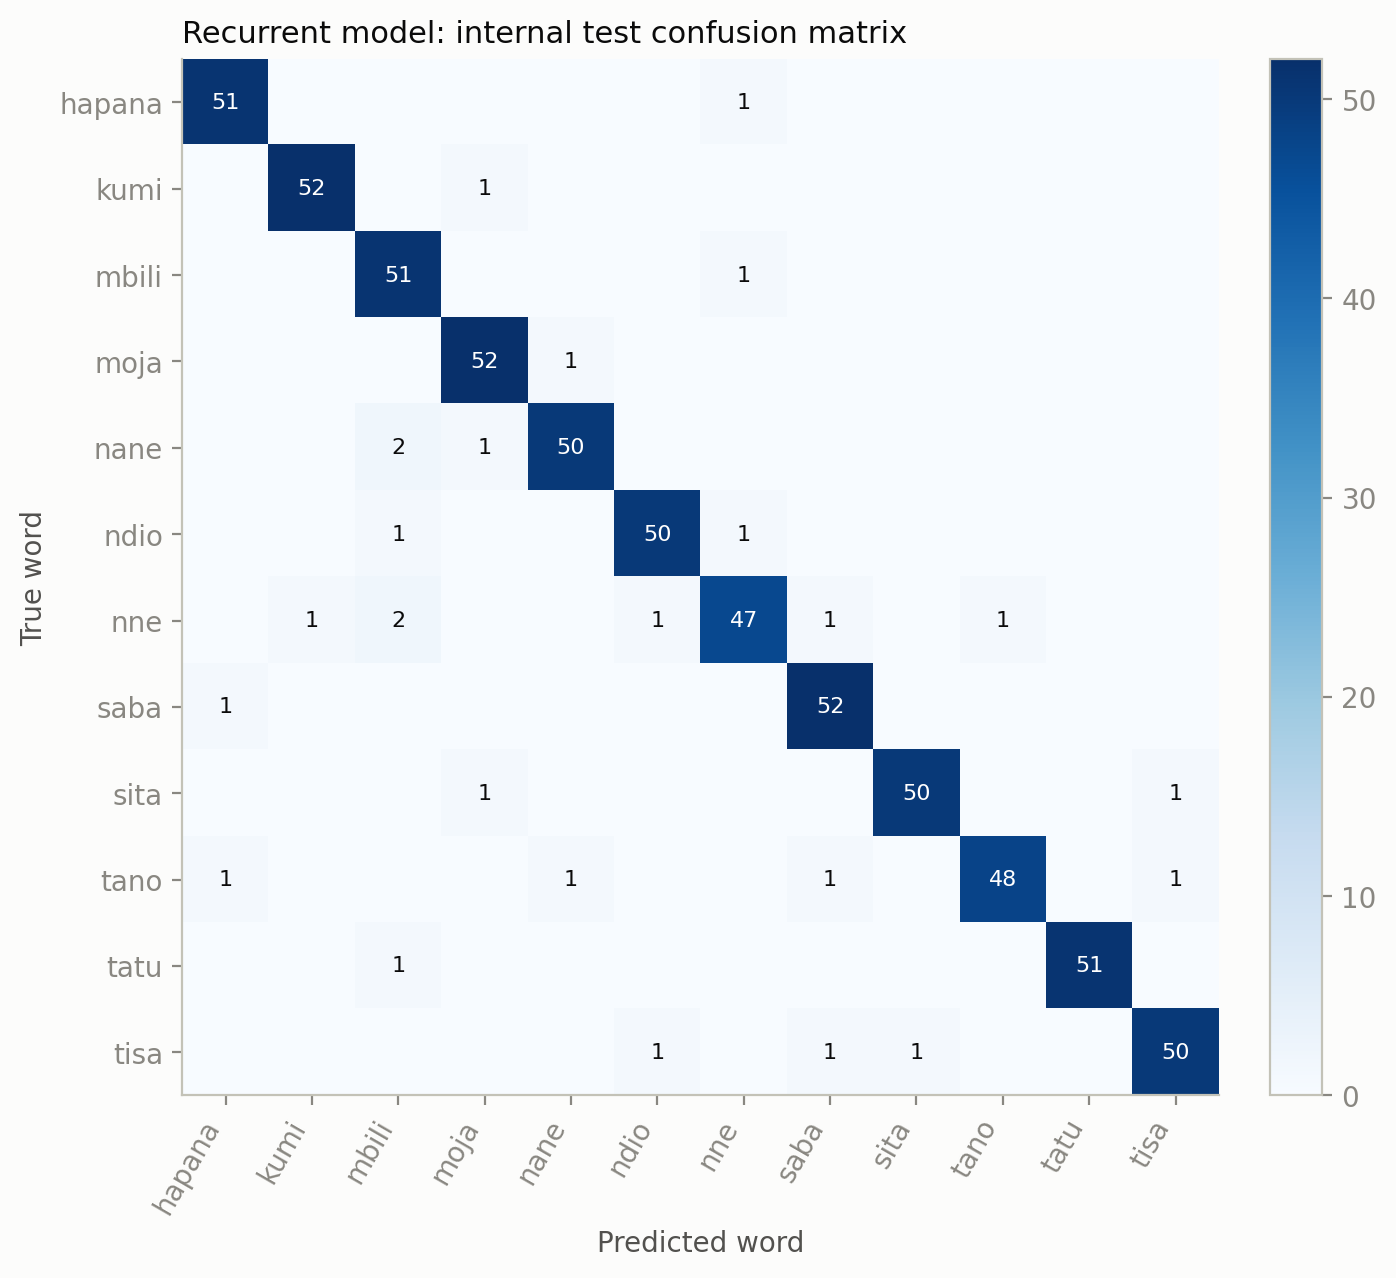

test_roc_curves


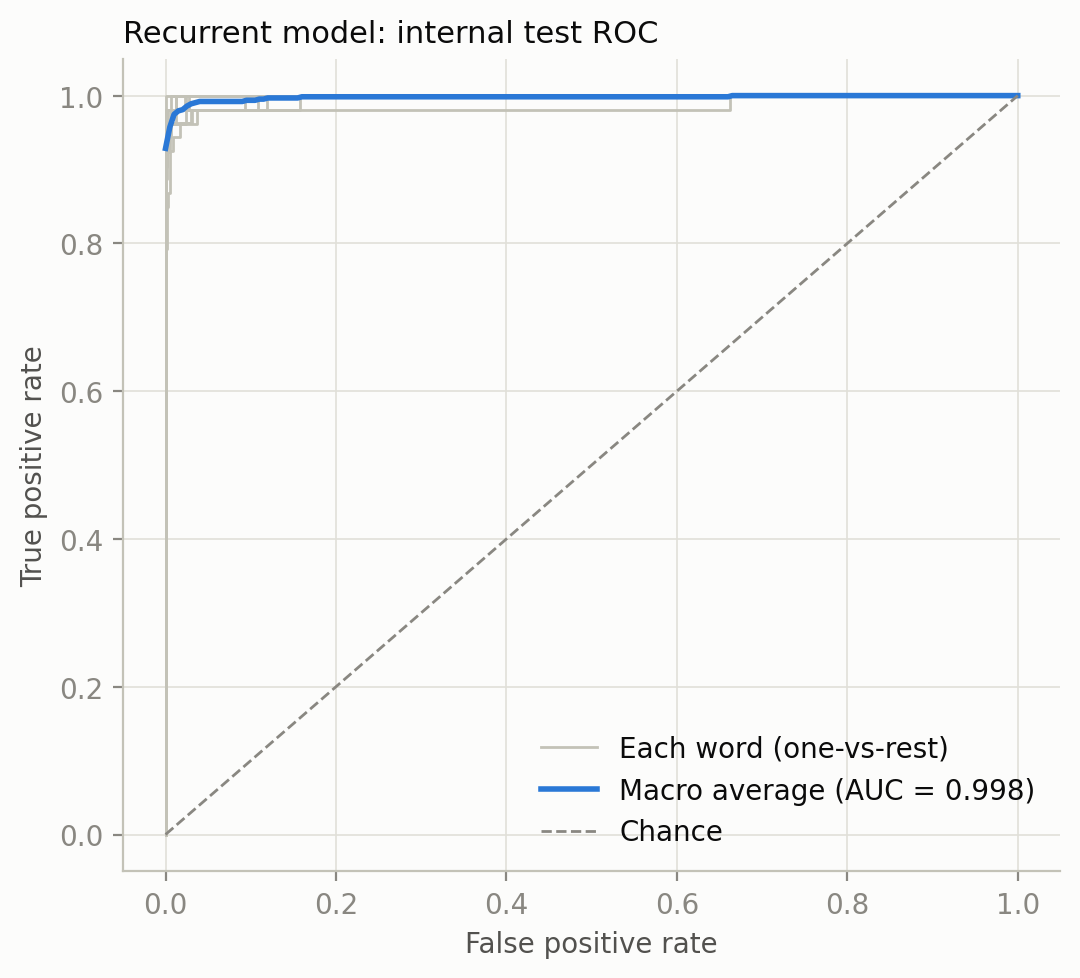

test_per_class_f1_vs_classical


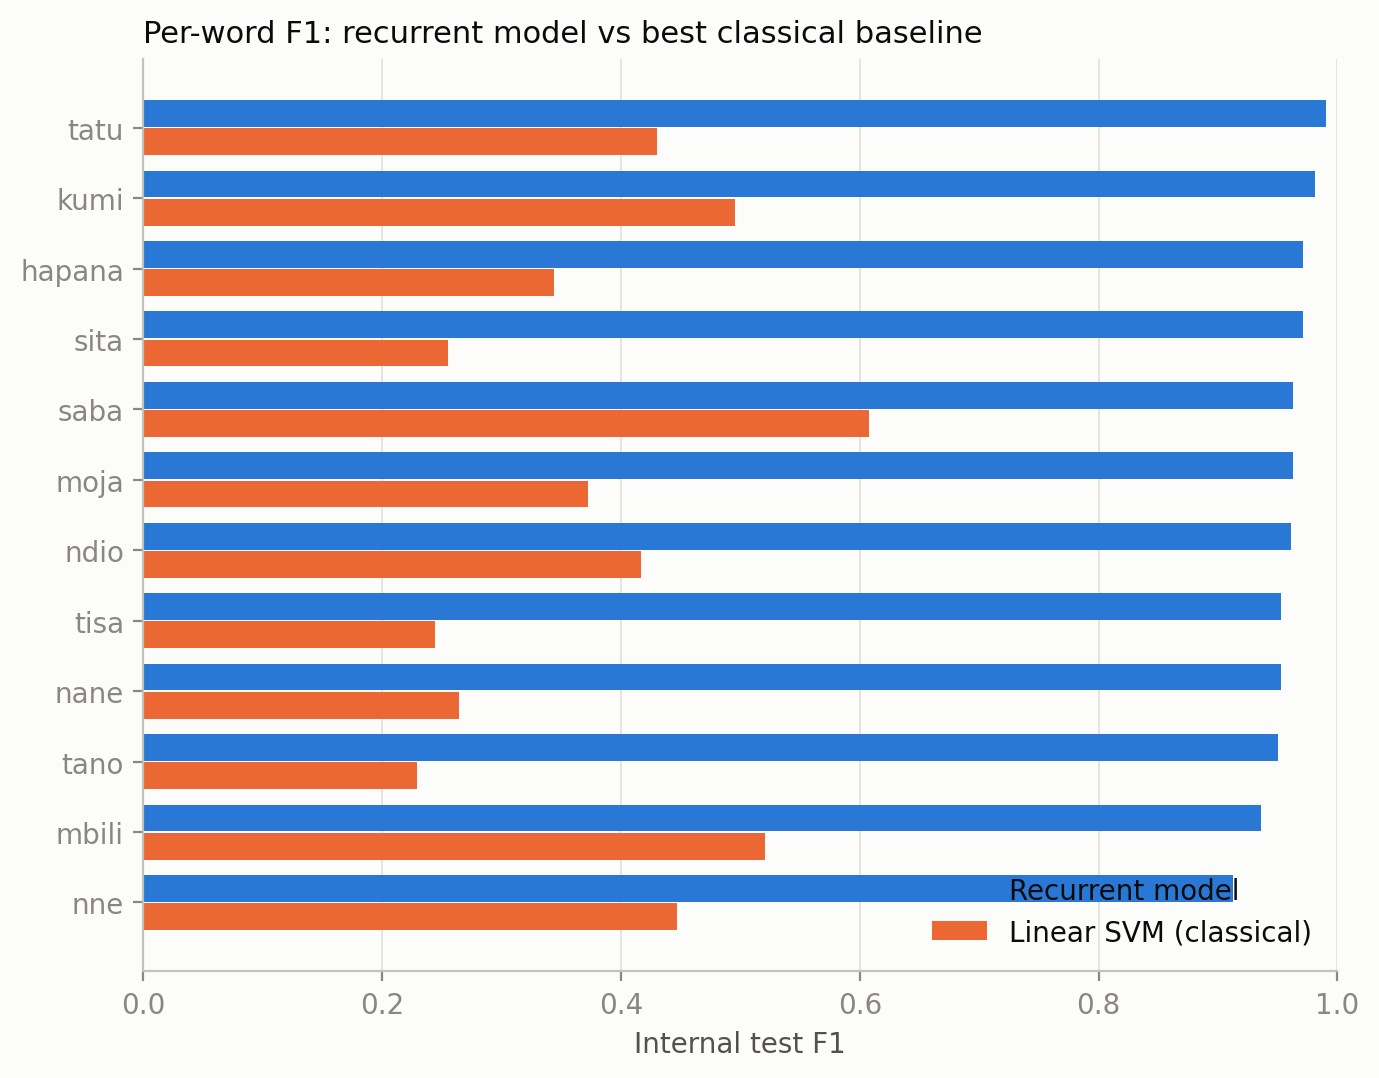

test_accuracy_by_duration


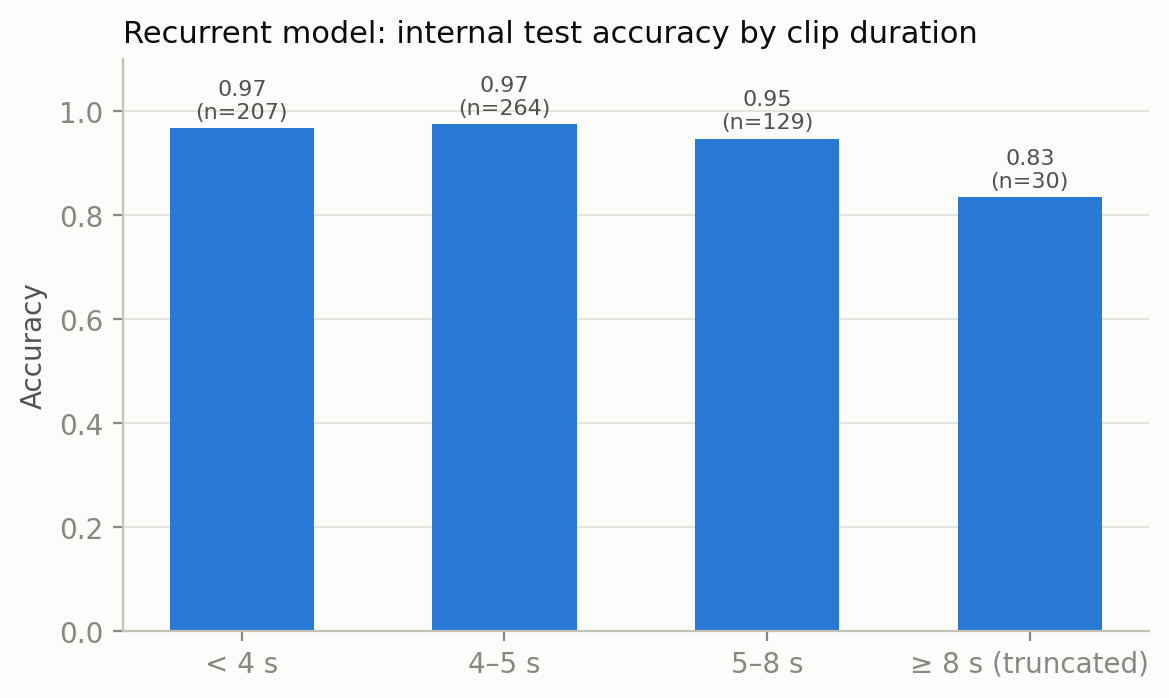

In [7]:
for name in ["validation_experiments", "learning_curves", "test_confusion_matrix", "test_roc_curves",
             "test_per_class_f1_vs_classical", "test_accuracy_by_duration"]:
    print(name)
    display(Image(filename=str(fig / f"{name}.png"), width=720))

## Save results to Drive (Colab only)

The Colab disk is wiped when the session ends. This copies the results and figures to Drive, without the feature cache or checkpoints. Download the folder, then copy `results/models/recurrent/` and `results/figures/recurrent/` into the repository and commit them.

In [8]:
if IN_COLAB:
    dest = Path(DRIVE_RESULTS_DIR)
    for src in [out, fig]:
        target = dest / src
        if target.exists():
            shutil.rmtree(target)
        shutil.copytree(src, target, ignore=shutil.ignore_patterns("cache", "checkpoints"))
    print("Saved to", dest)

Saved to /content/drive/MyDrive/swahili_audio/person2_results
